# 10 · Comparing methods on all records

**Question.** How often do EPDE and sparse regression recover the true equation or system across repeated seeds?

**Protocol.** The fresh clean-data campaign covers 15 core records, two methods and five seeds: 150 requested runs. Every run uses its dataset configuration. The shared evaluation compares methods only where both support the problem and reports unsupported records separately.

**Metrics.** Truth on the front means a discovered equation or system has the true set of terms under documented equivalent forms. The compromise equation is selected without the truth. Per-run recovery, recovery for at least one seed, equation recovery and whole-system recovery are separate quantities.

**Running.** The commands below reproduce this campaign. The displayed report is generated from its saved records during this notebook execution. Completed, failed, timed-out and unsupported runs remain visible in the report.


In [1]:
# From a terminal, in the repository root:
#   python projects/pic/bench.py campaign --suite core \
#          --variants default,pysindy --noise 0 --seeds 0-4 --workers 2 \
#          --name baseline_clean_2026-10-09 --timeout 900
#   python projects/pic/bench.py report projects/pic/results/baseline_clean_2026-10-09

In [2]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
import epde_bench.nbcache as notebook_cache
if os.environ.get('EPDE_BENCH_NOTEBOOK_CACHE'):
    notebook_cache.CACHE_DIR = Path(os.environ['EPDE_BENCH_NOTEBOOK_CACHE'])
from epde_bench.env import seed_everything
seed_everything(0)
from epde_bench.identity import _source_hash
print('Computation source SHA256:', _source_hash())
print('Search cache:', notebook_cache.CACHE_DIR)
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

Computation source SHA256: e9af6c769476a35197f9f9a7b0d4ad401ca7b0edeec5bda9c53b9f636b810aa0
Search cache: <repo>/projects/pic/results/notebook_execution_2026-10-09/search_cache
EPDE imported; notebook environment ready


In [3]:
print((PIC / 'configs' / 'variants.yaml').read_text())

# Method variants compared by the benchmark. Each entry is merged on top of the
# shared protocol and the file of the record. The default variant changes
# nothing: EPDE as shipped (percentage discrepancy, instability as the second
# Pareto axis, variance-weighted sparsity) with the finite differences of the
# shared protocol.

default: {}

# Old EPDE: L2 discrepancy, LASSO sparsity, complexity as the second axis
# (the earlier pipeline of the group's former benchmark).
legacy:
  search:
    objectives:
      discrepancy_metric: l2
      sparsity_cls: lasso
      sparsity_kwargs: {initial_sparsity_interval: [1.0e-12, 1.0e-4]}
      second_objective: complexity

# Derivatives from local polynomial fits instead of finite differences.
poly:
  search:
    preprocessing:
      default_preprocessor_type: poly

# Support chosen by the knee of the residual-vs-size curve.
knee:
  search:
    objectives:
      sparsity_cls: knee

# Instability measured by cross-validation over windows.
instab_cv

In [4]:
import pandas as pd
from IPython.display import Markdown, display, Image
from epde_bench.paths import RESULTS_DIR
campaign_name = os.environ.get('EPDE_BENCH_NOTEBOOK_CAMPAIGN', 'baseline_clean_2026-10-09')
live_campaign = RESULTS_DIR / campaign_name
published_campaign = PIC / 'experiments' / campaign_name
CAMPAIGN = live_campaign if (live_campaign / 'runs').is_dir() else published_campaign
CAMPAIGN_IS_LIVE = CAMPAIGN == live_campaign
REPORT_DIR = CAMPAIGN / 'report'
print('Campaign:', CAMPAIGN)
print('Report source:', 'local campaign; report will be regenerated' if CAMPAIGN_IS_LIVE else 'published evidence; existing report is read without modification')
print('campaign results available:', (CAMPAIGN / 'runs').exists())

Campaign: <repo>/projects/pic/results/baseline_clean_2026-10-09
Report source: local campaign; report will be regenerated
campaign results available: True


report written to <repo>/projects/pic/results/baseline_clean_2026-10-09/report


# Campaign `baseline_clean_2026-10-09`

Runs: 150 (ok: 130, timeout: 10, unsupported: 10).
Success: the true structure (or an accepted equivalent form) is on the final Pareto front; "pick": the equation chosen from the front without knowing the truth (compromise) is correct. Cells: k/n (rate, 95 % Wilson interval). Errors and timeouts count as misses. pending: planned, not yet run; unsupported: the method cannot represent the problem. These two statuses are excluded from the denominators.

## Noise 0 %

### Truth on the Pareto front

| dataset | default | pysindy |
|---|---|---|
| ac | 4/5 (80%, 38-96) | 0/5 (0%, 0-43) |
| burgers | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| burgers_inviscid | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| duffing | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| kdv | 2/5 (40%, 12-77) | 0/5 (0%, 0-43) |
| kdv_cossin | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| ks | 0/5 (0%, 0-43) | 0/5 (0%, 0-43) |
| lorenz | 0/5 (0%, 0-43) | 5/5 (100%, 57-100) |
| lv | 2/5 (40%, 12-77) | 5/5 (100%, 57-100) |
| ns | 0/5 (0%, 0-43) |  |
| ode | 4/5 (80%, 38-96) | 5/5 (100%, 57-100) |
| pde_compound | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| pde_divide | 5/5 (100%, 57-100) |  |
| vdp | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| wave | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |

### Compromise pick is correct

| dataset | default | pysindy |
|---|---|---|
| ac | 0/5 (0%, 0-43) | 0/5 (0%, 0-43) |
| burgers | 3/5 (60%, 23-88) | 5/5 (100%, 57-100) |
| burgers_inviscid | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| duffing | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| kdv | 2/5 (40%, 12-77) | 0/5 (0%, 0-43) |
| kdv_cossin | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| ks | 0/5 (0%, 0-43) | 0/5 (0%, 0-43) |
| lorenz | 0/5 (0%, 0-43) | 5/5 (100%, 57-100) |
| lv | 2/5 (40%, 12-77) | 5/5 (100%, 57-100) |
| ns | 0/5 (0%, 0-43) |  |
| ode | 3/5 (60%, 23-88) | 5/5 (100%, 57-100) |
| pde_compound | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| pde_divide | 5/5 (100%, 57-100) |  |
| vdp | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |
| wave | 5/5 (100%, 57-100) | 5/5 (100%, 57-100) |

## Best variant per problem class

Mean over the data sets of the class supported by every variant of the per-set success rate; a data set is left out of the ranking when any variant is unsupported on it or has no finished runs yet. Ties are broken by the compromise pick, then by speed.

| class | noise, % | best variant | success (front) | success (pick) | median time, s |
|---|---|---|---|---|---|
| ODE | 0 | pysindy | 100% | 100% | 1 |
| ODE system | 0 | pysindy | 100% | 100% | 2 |
| PDE 1-D | 0 | default | 78% | 62% | 94 |

## All data sets together (mean success on the front)

| variant | 0.0 |
|---|---|
| pysindy | 77% |
| default | 72% |

## Median search time, s

| dataset | default | pysindy |
|---|---|---|
| ac | 39.7 | 9.0 |
| burgers | 62.1 | 23.7 |
| burgers_inviscid | 106.5 | 10.9 |
| duffing | 34.6 | 1.8 |
| kdv | 214.6 | 154.8 |
| kdv_cossin | 94.5 | 7.1 |
| ks |  | 225.2 |
| lorenz | 176.6 | 2.3 |
| lv | 42.8 | 1.6 |
| ode | 12.3 | 1.2 |
| pde_compound | 144.1 | 33.3 |
| pde_divide | 284.0 |  |
| vdp | 26.4 | 1.5 |
| wave | 63.7 | 7.7 |

## Failed runs

- ks / default / noise 0 / seed 0: timeout 
- ks / default / noise 0 / seed 1: timeout 
- ks / default / noise 0 / seed 2: timeout 
- ks / default / noise 0 / seed 3: timeout 
- ks / default / noise 0 / seed 4: timeout 
- ns / default / noise 0 / seed 0: timeout 
- ns / default / noise 0 / seed 1: timeout 
- ns / default / noise 0 / seed 2: timeout 
- ns / default / noise 0 / seed 3: timeout 
- ns / default / noise 0 / seed 4: timeout 

## Pending and unsupported runs

- ns / pysindy / noise 0 / seed 0: unsupported the baseline cannot represent the spatial continuity equation; one temporal equation per variable would substitute p_t for continuity
- ns / pysindy / noise 0 / seed 1: unsupported the baseline cannot represent the spatial continuity equation; one temporal equation per variable would substitute p_t for continuity
- ns / pysindy / noise 0 / seed 2: unsupported the baseline cannot represent the spatial continuity equation; one temporal equation per variable would substitute p_t for continuity
- ns / pysindy / noise 0 / seed 3: unsupported the baseline cannot represent the spatial continuity equation; one temporal equation per variable would substitute p_t for continuity
- ns / pysindy / noise 0 / seed 4: unsupported the baseline cannot represent the spatial continuity equation; one temporal equation per variable would substitute p_t for continuity
- pde_divide / pysindy / noise 0 / seed 0: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token
- pde_divide / pysindy / noise 0 / seed 1: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token
- pde_divide / pysindy / noise 0 / seed 2: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token
- pde_divide / pysindy / noise 0 / seed 3: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token
- pde_divide / pysindy / noise 0 / seed 4: unsupported the baseline cannot represent x*u_t on the left-hand side and has no inverse-x coefficient token


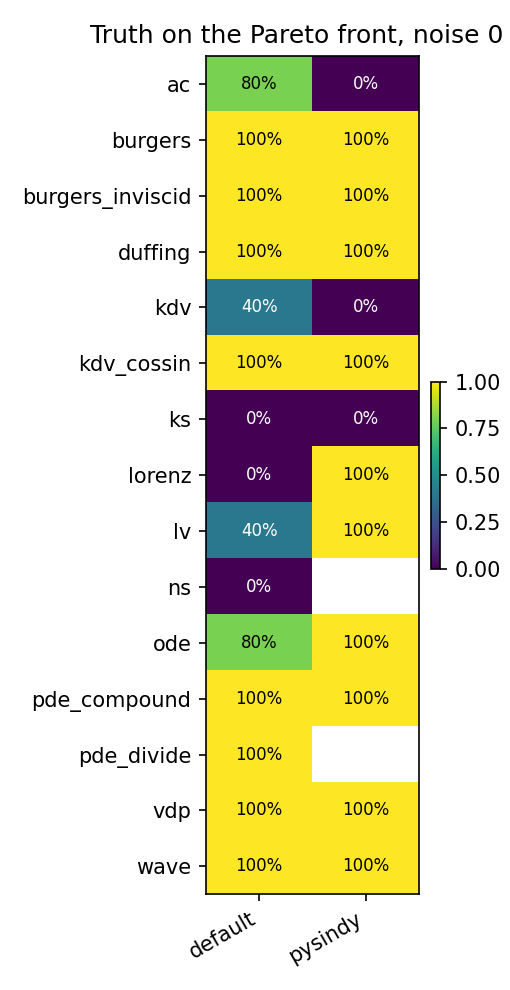

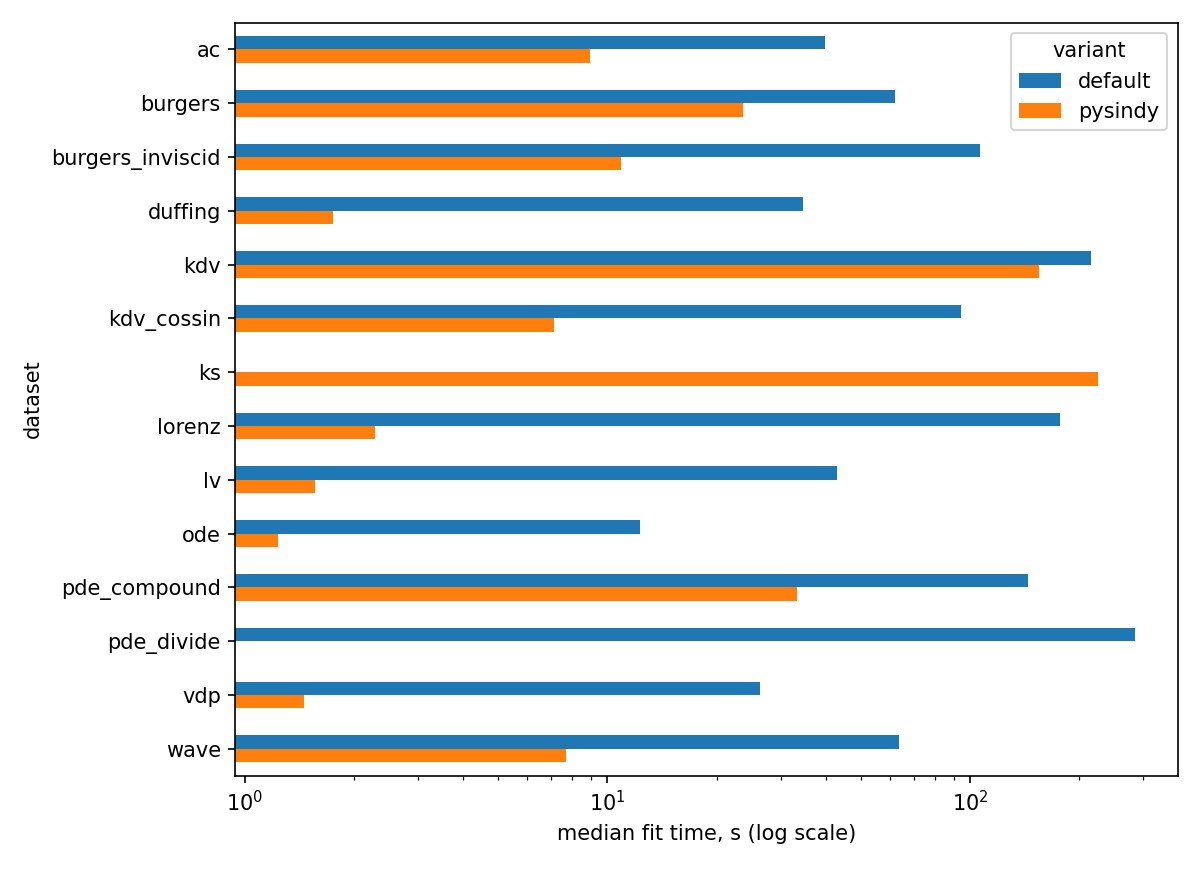

In [5]:
if CAMPAIGN_IS_LIVE and (CAMPAIGN / 'runs').exists():
    from epde_bench.report import make_report
    REPORT_DIR = make_report(CAMPAIGN)
if (REPORT_DIR / 'summary.md').is_file():
    display(Markdown((REPORT_DIR / 'summary.md').read_text(encoding='utf-8')))
    for png in sorted(REPORT_DIR.glob('fig_*.png')):
        display(Image(filename=str(png)))
else:
    print('Campaign report is unavailable; run the campaign and report commands above.')

In [6]:
# Pending and unsupported runs are reported separately, not as failures.
if (REPORT_DIR / 'success_front.csv').exists():
    display(pd.read_csv(REPORT_DIR / 'success_front.csv'))
    display(pd.read_csv(REPORT_DIR / 'ranking.csv'))

,dataset,variant,noise,kind,runs,planned,pending,unsupported,success_front,success_selected,median_fit_s,median_coef_error,ranking_comparable
0,ac,default,0.0,pde_1d,5,5,0,0,0.8,0.0,39.701326,1.217606e-01,True
1,ac,pysindy,0.0,pde_1d,5,5,0,0,0.0,0.0,8.957004,NaN,True
2,burgers,default,0.0,pde_1d,5,5,0,0,1.0,0.6,62.113048,6.912078e-03,True
3,burgers,pysindy,0.0,pde_1d,5,5,0,0,1.0,1.0,23.654827,7.043133e-03,True
4,burgers_inviscid,default,0.0,pde_1d,5,5,0,0,1.0,1.0,106.530533,6.661338e-16,True
5,burgers_inviscid,pysindy,0.0,pde_1d,5,5,0,0,1.0,1.0,10.892098,4.617384e-05,True
6,duffing,default,0.0,ode,5,5,0,0,1.0,1.0,34.634230,6.712376e-04,True
7,duffing,pysindy,0.0,ode,5,5,0,0,1.0,1.0,1.755626,7.055891e-04,True
8,kdv,default,0.0,pde_1d,5,5,0,0,0.4,0.4,214.565278,9.699413e-03,True
9,kdv,pysindy,0.0,pde_1d,5,5,0,0,0.0,0.0,154.786735,NaN,True


,kind,noise,variant,success_front,success_selected,median_fit_s
0,ode,0.0,pysindy,1.000000,1.000000,1.454495
1,ode,0.0,default,0.933333,0.866667,26.401165
2,ode_system,0.0,pysindy,1.000000,1.000000,1.922403
3,ode_system,0.0,default,0.200000,0.200000,109.731945
4,pde_1d,0.0,default,0.775000,0.625000,94.477133
5,pde_1d,0.0,pysindy,0.625000,0.625000,17.273462
